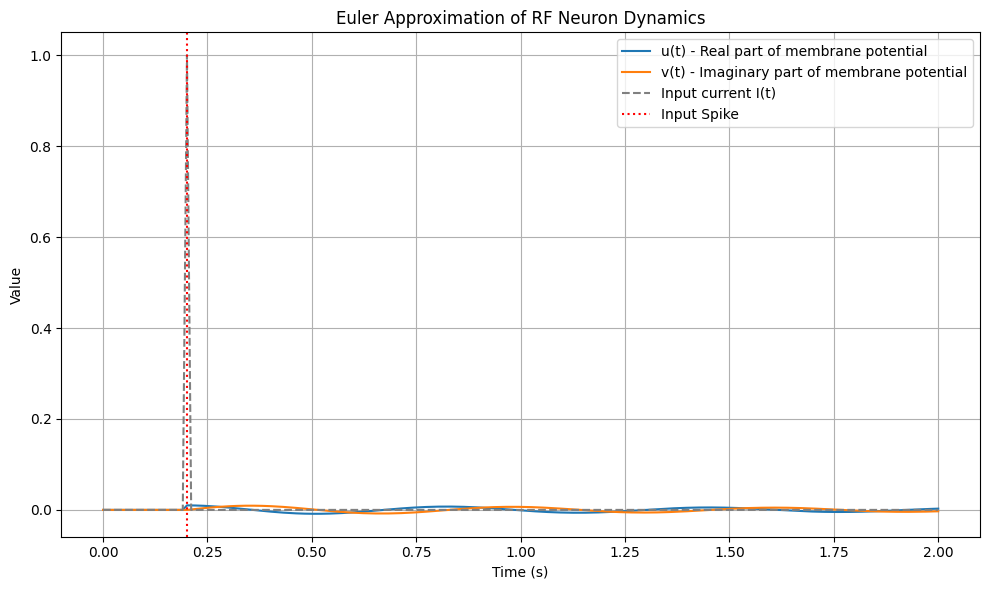

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters for a simple resonate-and-fire neuron
omega = 10.0  # angular frequency (rad/s)
b = -1.0      # damping factor
dt = 0.01     # time step
T = 2.0       # total time in seconds
steps = int(T / dt)

# Time array
t = np.linspace(0, T, steps)

# Input current: short pulse at t=0.2s
I = np.zeros(steps)
I[int(0.2 / dt)] = 1.0

# Initialize u and v (real and imaginary parts of membrane potential)
u = np.zeros(steps)
v = np.zeros(steps)

# Euler update loop
for i in range(1, steps):
    u[i] = u[i-1] + dt * (b * u[i-1] - omega * v[i-1] + I[i])
    v[i] = v[i-1] + dt * (omega * u[i-1] + b * v[i-1])

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, u, label='u(t) - Real part of membrane potential')
plt.plot(t, v, label='v(t) - Imaginary part of membrane potential')
plt.plot(t, I, label='Input current I(t)', linestyle='--', color='gray')
plt.axvline(x=0.2, color='red', linestyle=':', label='Input Spike')
plt.title('Euler Approximation of RF Neuron Dynamics')
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


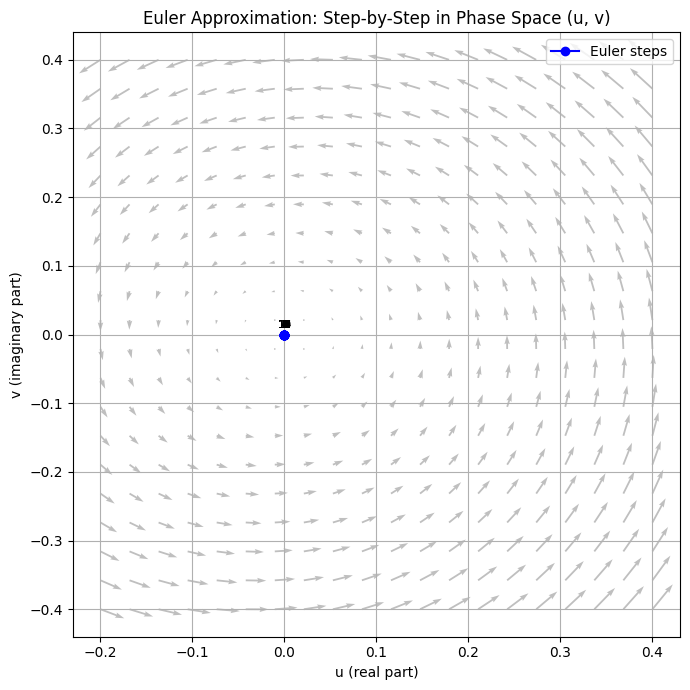

In [2]:
# Let's create a step-by-step visualization of how Euler approximation works
# for the first few steps after the input, illustrating the update process.

num_steps_to_visualize = 20  # only show first 20 steps for clarity

# Reset u and v
u_step = np.zeros(num_steps_to_visualize)
v_step = np.zeros(num_steps_to_visualize)

# Apply input at first step
I_step = np.zeros(num_steps_to_visualize)
I_step[0] = 1.0

# Perform Euler updates for a few steps
for i in range(1, num_steps_to_visualize):
    u_step[i] = u_step[i-1] + dt * (b * u_step[i-1] - omega * v_step[i-1] + I_step[i])
    v_step[i] = v_step[i-1] + dt * (omega * u_step[i-1] + b * v_step[i-1])

# Plot the vector field of (u, v) and Euler steps
U, V = np.meshgrid(np.linspace(-0.2, 0.4, 20), np.linspace(-0.4, 0.4, 20))
dU = b * U - omega * V
dV = omega * U + b * V

fig, ax = plt.subplots(figsize=(7, 7))
ax.quiver(U, V, dU, dV, color='gray', alpha=0.5)
ax.plot(u_step, v_step, 'o-', color='blue', label='Euler steps')
for i in range(num_steps_to_visualize):
    ax.annotate(f'{i}', (u_step[i], v_step[i]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

ax.set_title('Euler Approximation: Step-by-Step in Phase Space (u, v)')
ax.set_xlabel('u (real part)')
ax.set_ylabel('v (imaginary part)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()
